# Tutorial 02 — Quasiharmonic Approximation (QHA) with Machine-Learning Force Fields

## Background

We will obtain phonon frequencies at several different volumes, to determine the volume that minimises the free energy at each temperature. This will allow us to calculate thermal expansion coefficients, Grueneisen parameter and heat capacities as a function of temperature.

### Workflow steps

```
1. Relax structure at equilibrium volume
        ↓
2. Generate N volumes by applying uniform strain (linear_strain, number_of_frames)
        ↓
3. For each volume: relax ions at constant volume + compute phonon force constants
        ↓
4. Fit equation of state (EOS) to E(V) — here: Vinet EOS
        ↓
5. Combine EOS + phonon free energies → F(V, T) → minimize → V(T), α(T), γ(T)
```

### Machine-learning force fields
Instead of VASP, we use **universal MLIPs** to reduce the cost for the tutorial

In [ ]:
from jobflow import JobStore, run_locally
from maggma.stores import MemoryStore
from pymatgen.core import Structure
from fireworks import LaunchPad
from jobflow.managers.fireworks import flow_to_workflow
from atomate2.vasp.flows.qha import QhaMaker

from atomate2.forcefields.jobs import ForceFieldRelaxMaker
from atomate2.forcefields.jobs import ForceFieldStaticMaker
from atomate2.forcefields.flows.phonons import PhononMaker

si_structure = Structure.from_file("Si.cif")

pet_mad_kwargs = {"device": "cuda", "rotational_average_order": 3, "model": "pet-mad-s", "version": "1.5.0"} 
pet_mad_calculator="UPET"
bulk_relax_maker_petmad = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=True,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)
bulk_relax_maker_petmad_cv = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=False,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)

phonon_displacement_maker_petmad = ForceFieldStaticMaker(
    force_field_name=pet_mad_calculator,
    calculator_kwargs=pet_mad_kwargs,
)
phonon_displacement_maker_petmad.name = "pet-mad phonon static"

flow_petmad = QhaMaker(
    initial_relax_maker=bulk_relax_maker_petmad,
    eos_relax_maker=bulk_relax_maker_petmad_cv,
    min_length=10,
    phonon_maker=PhononMaker(
        generate_frequencies_eigenvectors_kwargs={
            "tmin": 0,
            "tmax": 500,
            "tstep": 10,
        },
        bulk_relax_maker=None,
        born_maker=None,
        static_energy_maker=phonon_displacement_maker_petmad,
        phonon_displacement_maker=phonon_displacement_maker_petmad,
    ),
    linear_strain=(-0.1, 0.1),
    number_of_frames=16,
    pressure=None,
    t_max=None,
    ignore_imaginary_modes=False,
    skip_analysis=False,
    eos_type="vinet",
).make(structure=si_structure)
workflow = flow_to_workflow(flow_petmad)
#only one person will submit the workflow 
#launchpad = LaunchPad.from_file("../my_launchpad.yaml")
#launchpad.add_wf(workflow)



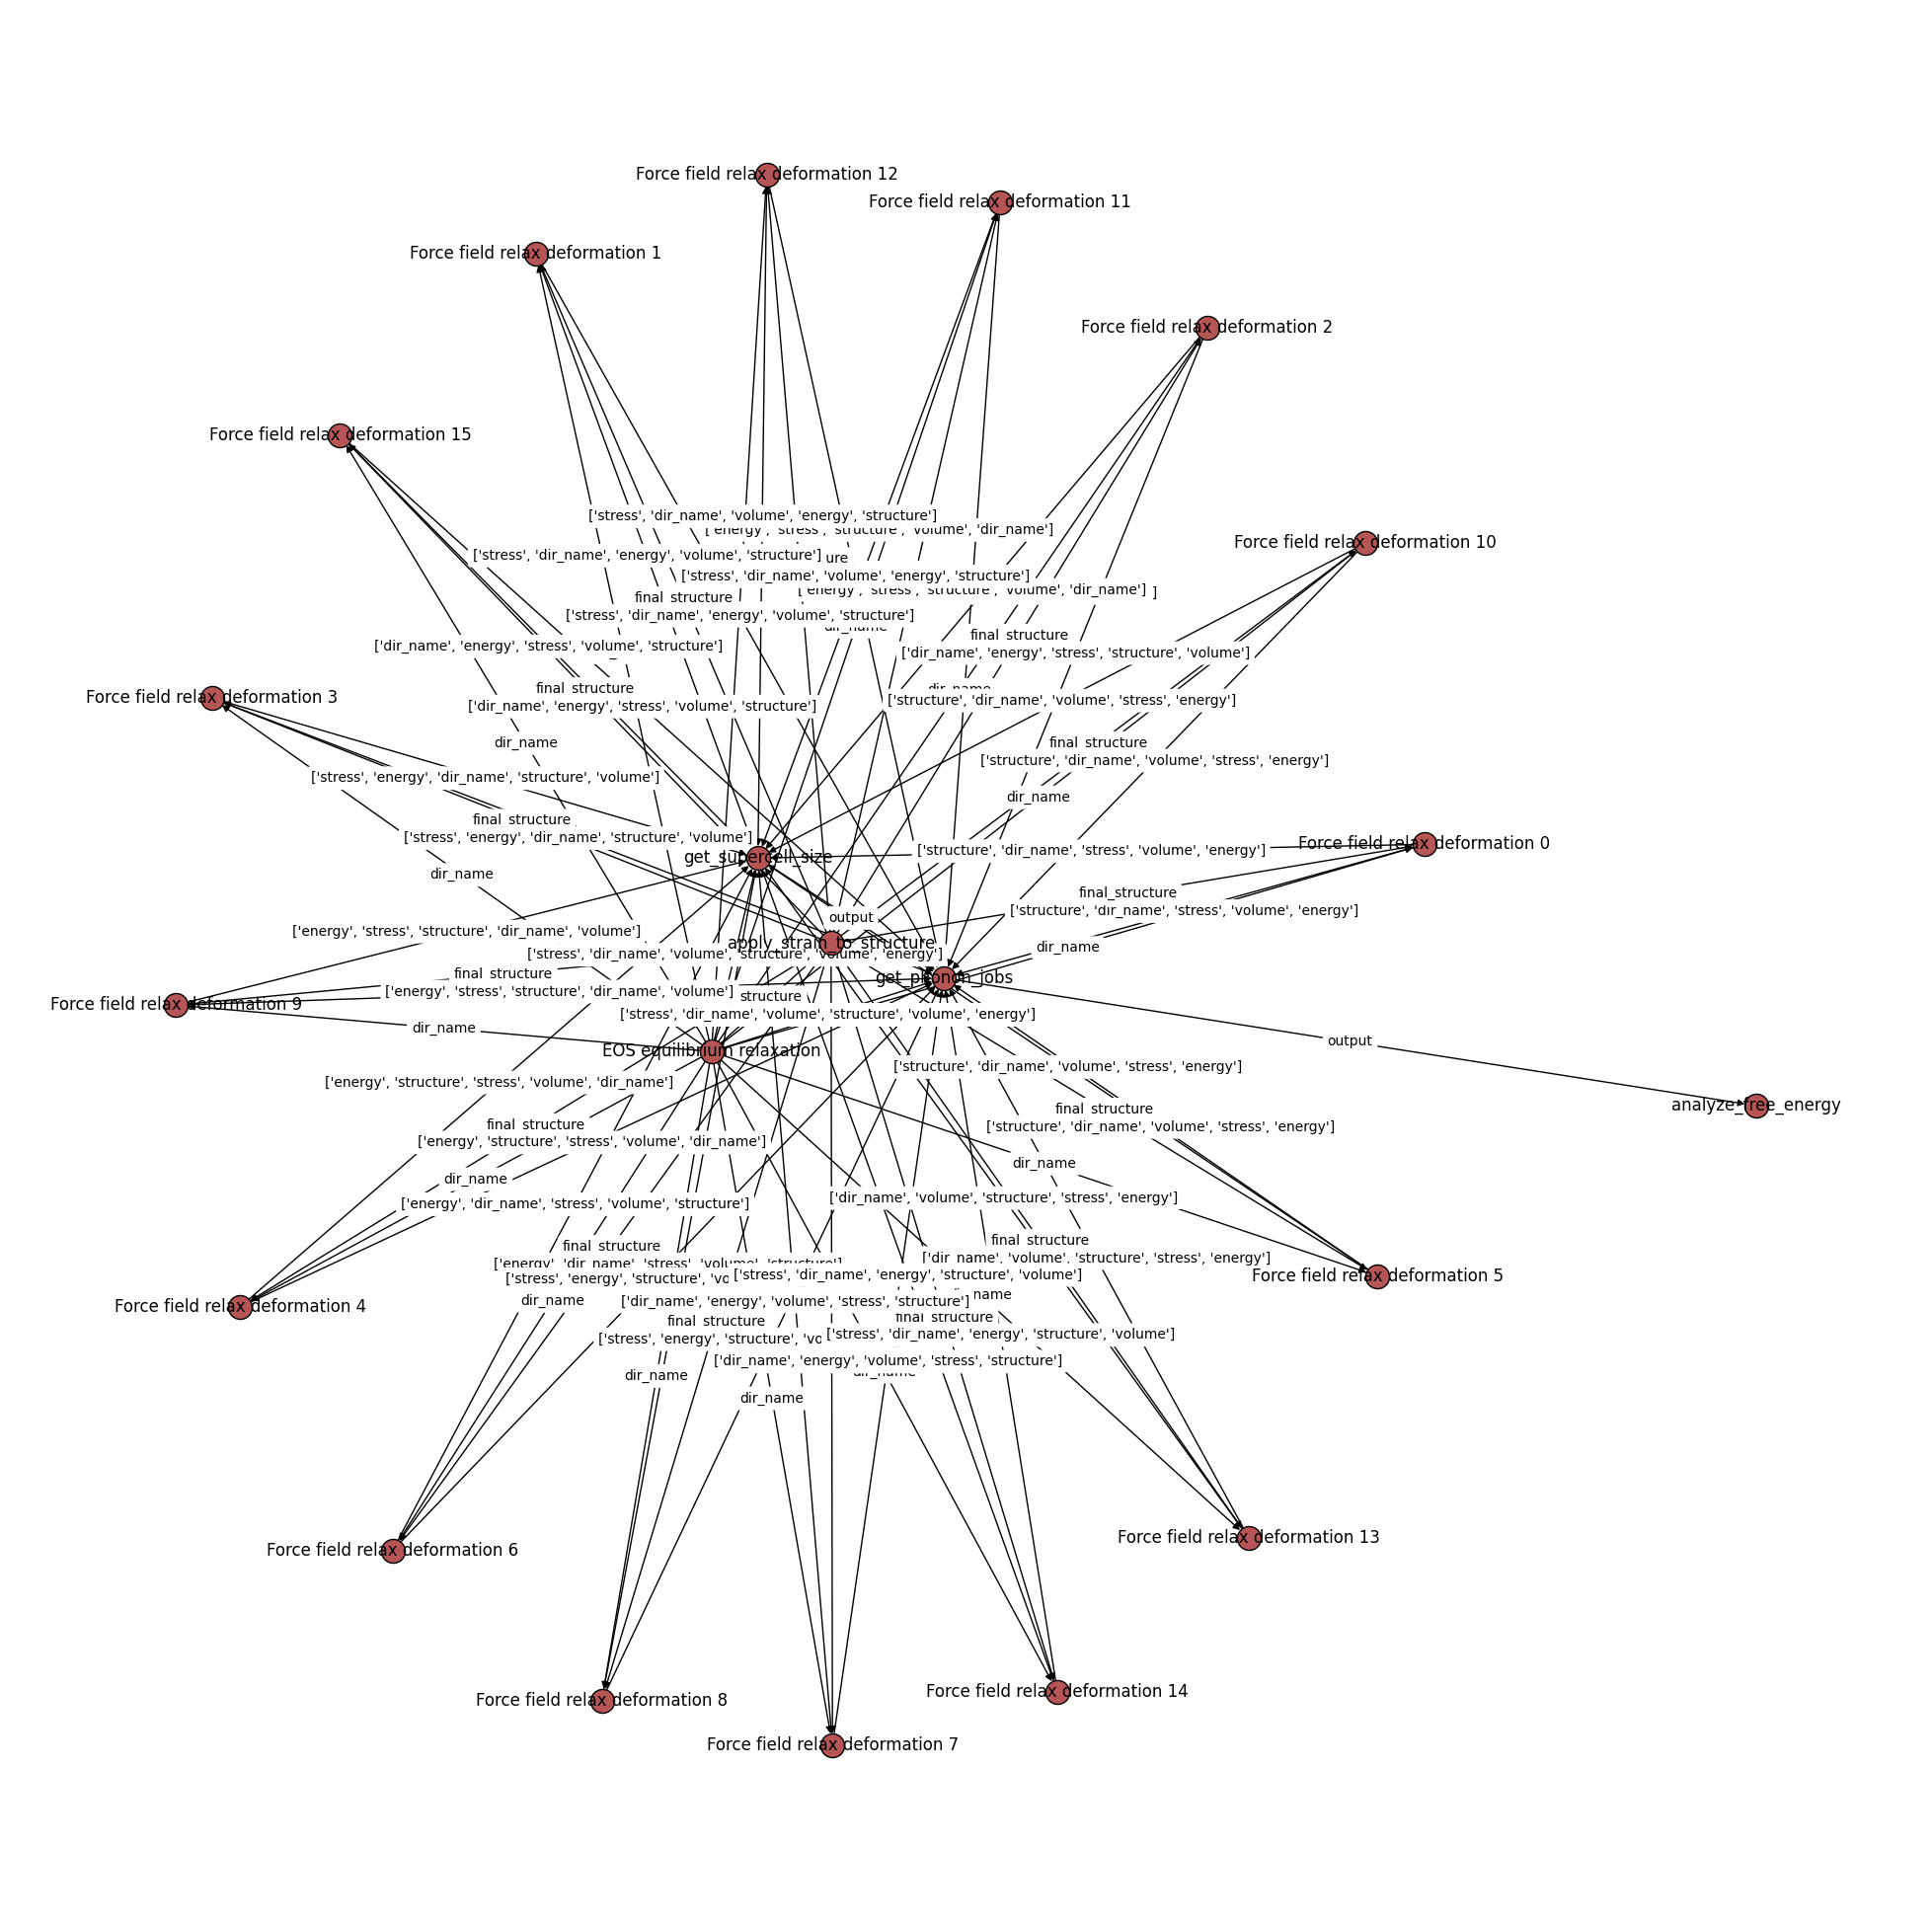

In [47]:
import networkx as nx
flow_petmad.draw_graph(figsize=(25, 25), layout_function=nx.nx_agraph.graphviz_layout).show()

We did not specify a worker so everybody can submit jobs on kuma to perform the calculations in parallel once the workflow is submitted.

In [ ]:
import yaml
from maggma.stores import MongoURIStore
from maggma.stores.gridfs import GridFSURIStore
from jobflow.core.store import JobStore
import matplotlib.pyplot as plt

from pymatgen.electronic_structure.plotter import DosPlotter, BSPlotter
from pymatgen.electronic_structure.dos import CompleteDos
from pymatgen.electronic_structure.bandstructure import BandStructureSymmLine

# Read connection URIs from the config file
with open("../jobflow.yaml") as f:
    jf_config = yaml.safe_load(f)

# The server we have at the moment can time out while fetching large QHA blobs
#  so we will adjust the timeout settings for both the docs and data stores.
timeout_kwargs = {"serverSelectionTimeoutMS": 120_000, "socketTimeoutMS": 300_000}

docs_store = MongoURIStore(
    uri=jf_config["JOB_STORE"]["docs_store"]["uri"],
    collection_name="outputs",
    mongoclient_kwargs=timeout_kwargs,
)
data_store = GridFSURIStore(
    uri=jf_config["JOB_STORE"]["additional_stores"]["data"]["uri"],
    collection_name="outputs_blobs",
    mongoclient_kwargs=timeout_kwargs,
)
store = JobStore(docs_store=docs_store, additional_stores={"data": data_store})
store.connect()

result = store.query_one(
    {"name": "analyze_free_energy"},
    properties=[
        "output"
    ],
    load=True,
    sort={"completed_at": -1},
)

### Thermal expansion coefficient and equilibrium volume vs temperature

The left y-axis shows equilibrium volume V(T); the right y-axis shows the volumetric thermal expansion coefficient α(T). Silicon has a well-known anomaly: α is **negative** below ~120 K (negative thermal expansion), which a good MLFF should reproduce.

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_330715/1706026258.py:3: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel("Volume [$\AA^3$]")


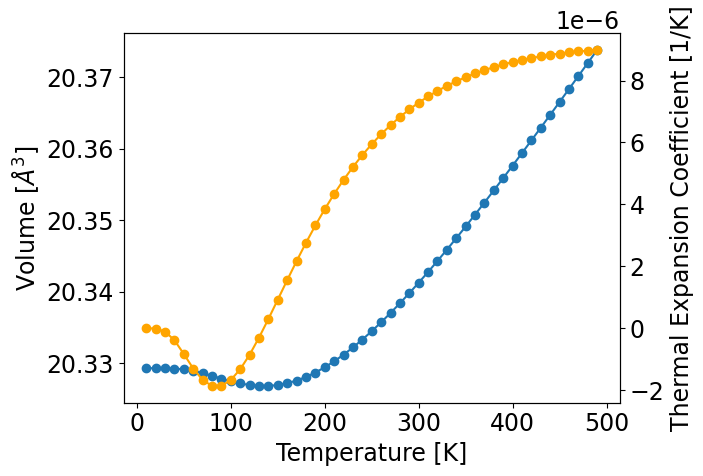

In [20]:
plt.plot(result['output']['temperatures'][1:], result['output']['volume_temperature'], marker="o")
plt.xlabel("Temperature [K]")
plt.ylabel("Volume [$\AA^3$]")
ax2 = plt.gca().twinx()
ax2.plot(result['output']['temperatures'][1:], result['output']['thermal_expansion'], marker="o", color="orange")
ax2.set_ylabel("Thermal Expansion Coefficient [1/K]")
plt.show()

### Grüneisen parameter vs temperature

The Grüneisen parameter γ describes how phonon frequencies shift with volume: γ = −d(ln ω)/d(ln V). A positive γ means modes soften as the crystal expands (normal behaviour). Values around 1–2 are typical for simple semiconductors like Si.

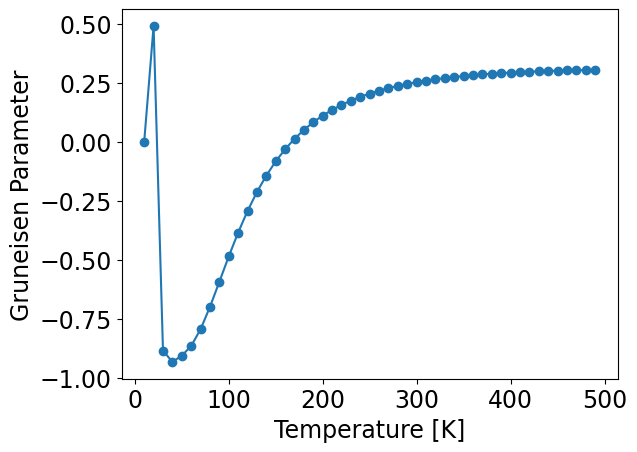

In [39]:
plt.plot(result['output']['temperatures'][1:], result['output']['gruneisen_temperature'], marker="o")
plt.xlabel("Temperature [K]")
plt.ylabel("Gruneisen Parameter")
plt.show()

## TODO

Run the same workflow with another universal model of your choice https://materialsproject.github.io/atomate2/user/codes/forcefields.html and compare the thermal expansion and gruneisen parameter results (only mace and upet are already installed in the environment on kuma). 